In [1]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages

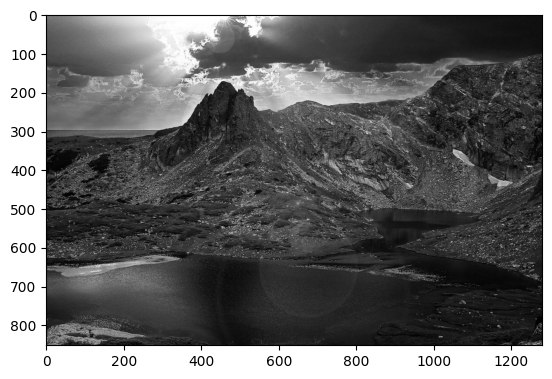

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%load_ext autoreload
%autoreload 2
import toolbox

img_bgr = cv2.imread('mountain.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray = img_gray.astype(np.float32)

plt.imshow(img_gray, cmap='gray')
plt.show()

# --- PARTIE I : Test et Validation des Gradients ---

---

Cette section permet de valider la précision des gradients calculés manuellement ($dx$ et $dy$) en les comparant aux versions de référence.

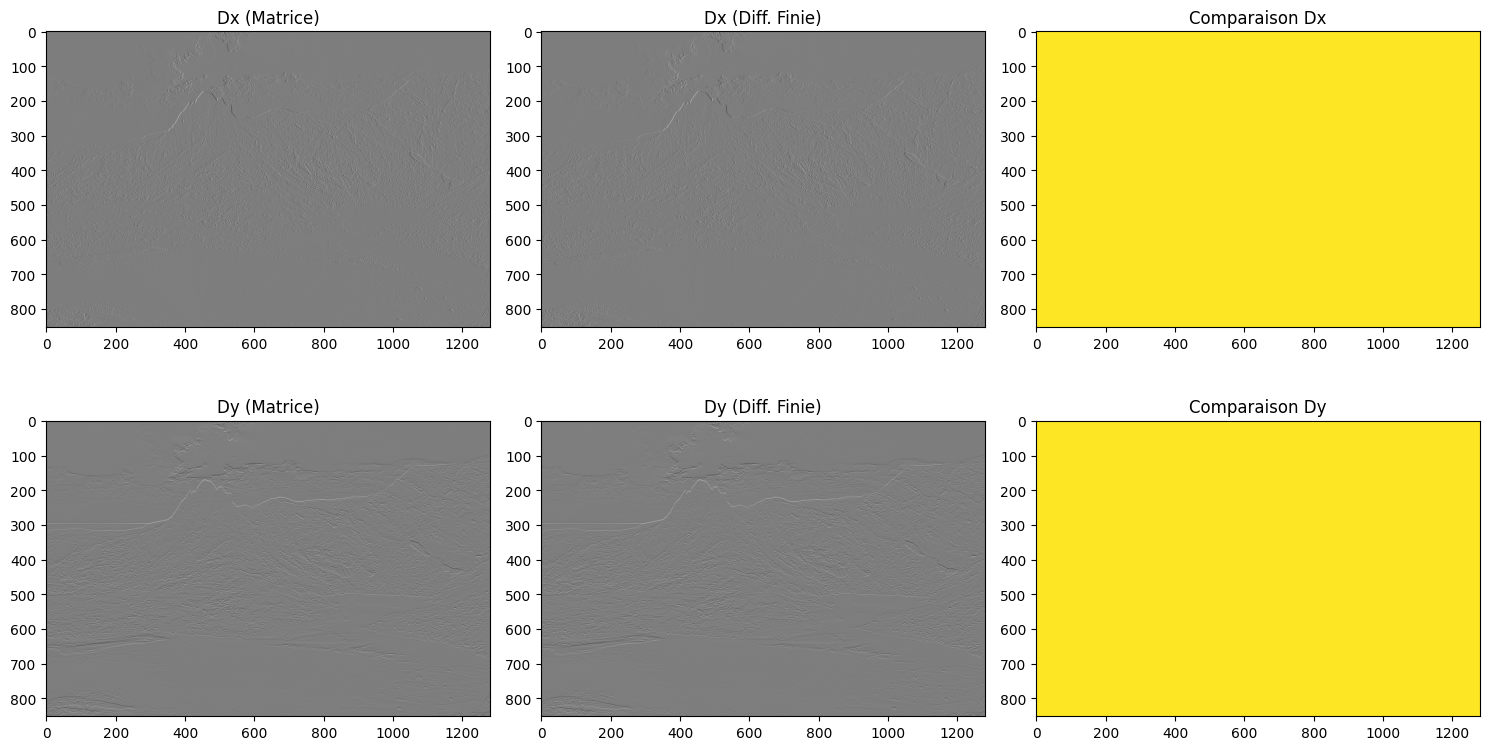

In [3]:
Dx, Dy = toolbox.build_Dx_Dy(img_bgr)
toolbox.comparer_gradients(img_bgr, Dx, Dy)

# --- PARTIE II : Test et Validation de WLS ---

--- 

In [4]:
alpha = 1.5
eps = 1e-4
lamb = 0.5

img_test = cv2.imread('photo_de_test.png')
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

In [ ]:
img_lisse = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=0.25)

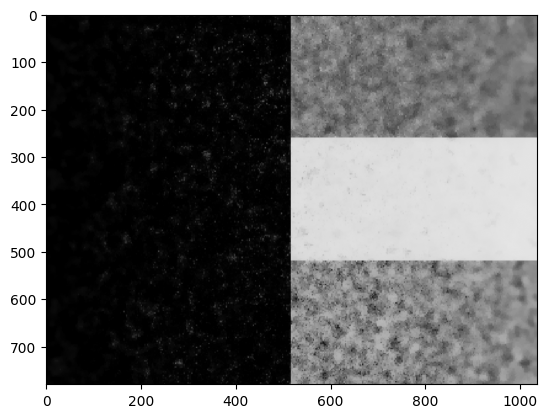

In [9]:
plt.imshow(img_lisse, cmap='gray')
plt.show()